In [1]:
%load_ext autoreload
%autoreload 2

import jax
import healpy as hp
import numpy as np
# FGBUSTER IMPORTS
import healpy as hp
import pysm3

from fgbuster import get_observation, get_instrument
from furax.comp_sep import spectral_cmb_variance , get_clusters , optimize

import jax
import jax.numpy as jnp
from jax import ShapeDtypeStruct

from furax._base.blocks import BlockDiagonalOperator, BlockRowOperator
from furax._base.core import HomothetyOperator, IdentityOperator
from furax.landscapes import StokesPyTree, ValidStokesType, HealpixLandscape
from furax.tree import as_structure
from furax.operators.sed import CMBOperator, DustOperator, SynchrotronOperator, MixingMatrixOperator
import operator
from math import prod
import numpy as np
from functools import partial

import os
import pickle

In [45]:
nu

NameError: name 'nu' is not defined

In [2]:
GAL020 = np.load("GAL_PlanckMasks_64.npz")['GAL020']
GAL040 = np.load("GAL_PlanckMasks_64.npz")['GAL040']
GAL060 = np.load("GAL_PlanckMasks_64.npz")['GAL060']

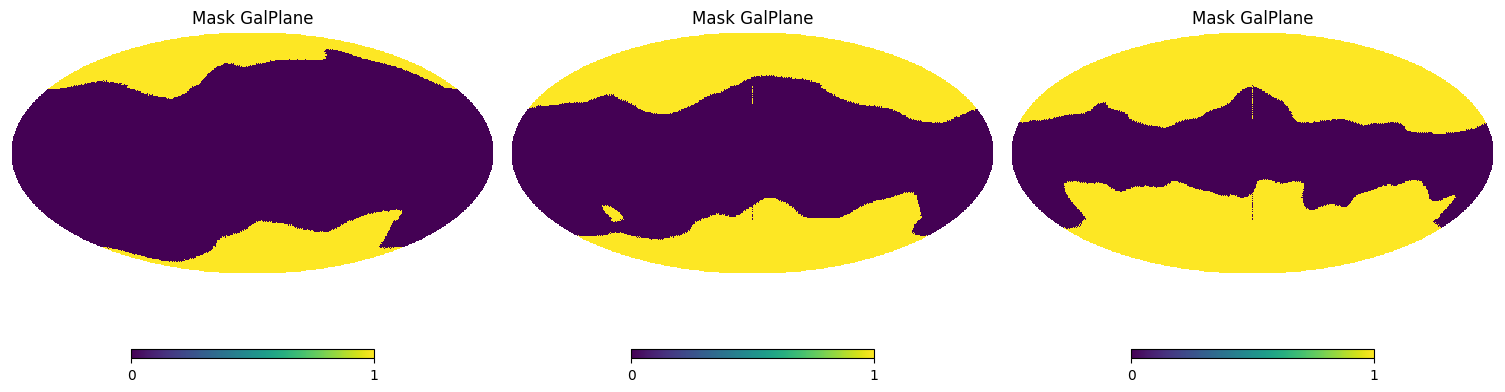

In [3]:
import matplotlib.pyplot as plt
figure = plt.figure(figsize=(15, 15))
hp.mollview(GAL020, title='Mask GalPlane' , sub=(1 ,3 , 1))
hp.mollview(GAL040, title='Mask GalPlane' , sub=(1 ,3 , 2))
hp.mollview(GAL060, title='Mask GalPlane' , sub=(1 ,3, 3))


In [4]:
beta_dust_patches = get_clusters(GAL020 , 10 , jax.random.PRNGKey(0))
beta_pl_patches = get_clusters(GAL020 , 5 , jax.random.PRNGKey(0))
temp_dust_patches = get_clusters(GAL020 , 8 , jax.random.PRNGKey(0))
figure = plt.figure(figsize=(15, 15))
hp.mollview(beta_dust_patches, title='Mask GalPlane' , sub=(1 ,3 , 1))
hp.mollview(beta_pl_patches, title='Mask GalPlane' , sub=(1 ,3 , 2))
hp.mollview(temp_dust_patches, title='Mask GalPlane' , sub=(1 ,3, 3))

2024-12-02 01:48:50.682081: W external/xla/xla/service/platform_util.cc:206] unable to create StreamExecutor for CUDA:0: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


RuntimeError: Unable to initialize backend 'cuda': INTERNAL: no supported devices found for platform CUDA (you may need to uninstall the failing plugin package, or set JAX_PLATFORMS=cpu to skip this backend.)

In [41]:
instrument = get_instrument('LiteBIRD')


def generate_maps(nside):
    npixel = nside**2 * 12
    # Define cache file path
    cache_dir = 'freq_maps_cache'
    os.makedirs(cache_dir, exist_ok=True)
    cache_file = os.path.join(cache_dir, f'freq_maps_nside_{nside}.pkl')

    # Check if file exists, load if it does, otherwise create and save it
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            freq_maps = pickle.load(f)
        print(f'Loaded freq_maps for nside {nside} from cache.')
    else:
        # Generate freq_maps if not already cached
        freq_maps = get_observation(instrument, 'c1d0s0', nside=nside)

        # Save freq_maps to the cache
        with open(cache_file, 'wb') as f:
            pickle.dump(freq_maps, f)
        print(f'Generated and saved freq_maps for nside {nside}.')

    # Check the shape of freq_maps
    print('freq_maps shape:', freq_maps.shape)


nsides = [32, 64, 128, 256, 512]
for nside in nsides:
    generate_maps(nside)

Loaded freq_maps for nside 32 from cache.
freq_maps shape: (15, 3, 12288)
Loaded freq_maps for nside 64 from cache.
freq_maps shape: (15, 3, 49152)
Loaded freq_maps for nside 128 from cache.
freq_maps shape: (15, 3, 196608)
Loaded freq_maps for nside 256 from cache.
freq_maps shape: (15, 3, 786432)
Loaded freq_maps for nside 512 from cache.
freq_maps shape: (15, 3, 3145728)


In [46]:
nside = 64
npixel = nside**2 * 12
dust_nu0 = 150.0
synchrotron_nu0 = 20.0
stokes_type: ValidStokesType = 'IQU'
instrument = get_instrument('LiteBIRD')

# Define cache file path
cache_dir = 'freq_maps_cache'
cache_file = os.path.join(cache_dir, f'freq_maps_nside_{nside}.pkl')

# Check if file exists and load if it does; otherwise raise an error with guidance
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        freq_maps = pickle.load(f)
    print(f'Loaded freq_maps for nside {nside} from cache.')
else:
    raise FileNotFoundError(
        f'Cache file for freq_maps with nside {nside} not found.\n'
        f'Please generate it first by calling `generate_maps({nside})`.'
    )

# Check the shape of freq_maps
print('freq_maps shape:', freq_maps.shape)

Loaded freq_maps for nside 64 from cache.
freq_maps shape: (15, 3, 49152)


In [43]:
d = StokesPyTree.from_stokes(Q=freq_maps[:, 1, :], U=freq_maps[:, 2, :])
d.structure

StokesQUPyTree(q=ShapeDtypeStruct(shape=(15, 49152), dtype=float64), u=ShapeDtypeStruct(shape=(15, 49152), dtype=float64))

In [44]:
from furax.comp_sep import spectral_cmb_variance

spectral_cmb_variance = partial(
    spectral_cmb_variance, dust_nu0=dust_nu0, synchrotron_nu0=synchrotron_nu0
)

In [ ]:


stokes_type = d.stokes
nside = int(sqrt(d.shape[-1] // 12))
in_structure = HealpixLandscape(nside, stokes_type).structure

cmb = CMBOperator(nu, in_structure=in_structure)
dust = DustOperator(
    nu,
    frequency0=dust_nu0,
    temperature=params['temp_dust'],
    temperature_patch_indices=patch_indices['temp_dust_patches'],
    beta=params['beta_dust'],
    beta_patch_indices=patch_indices['beta_dust_patches'],
    in_structure=in_structure,
)
synchrotron = SynchrotronOperator(
    nu,
    frequency0=synchrotron_nu0,
    beta_pl=params['beta_pl'],
    beta_pl_patch_indices=patch_indices['beta_pl_patches'],
    in_structure=in_structure,
)

A = MixingMatrixOperator(cmb=cmb, dust=dust, synchrotron=synchrotron)